In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

In [2]:
state_array_1d = np.load(
    "/data2/mlqin/HFT4Ind/analysis_result/motivation/tsne_result/state_array_1d.npy"
)
bin_size=200


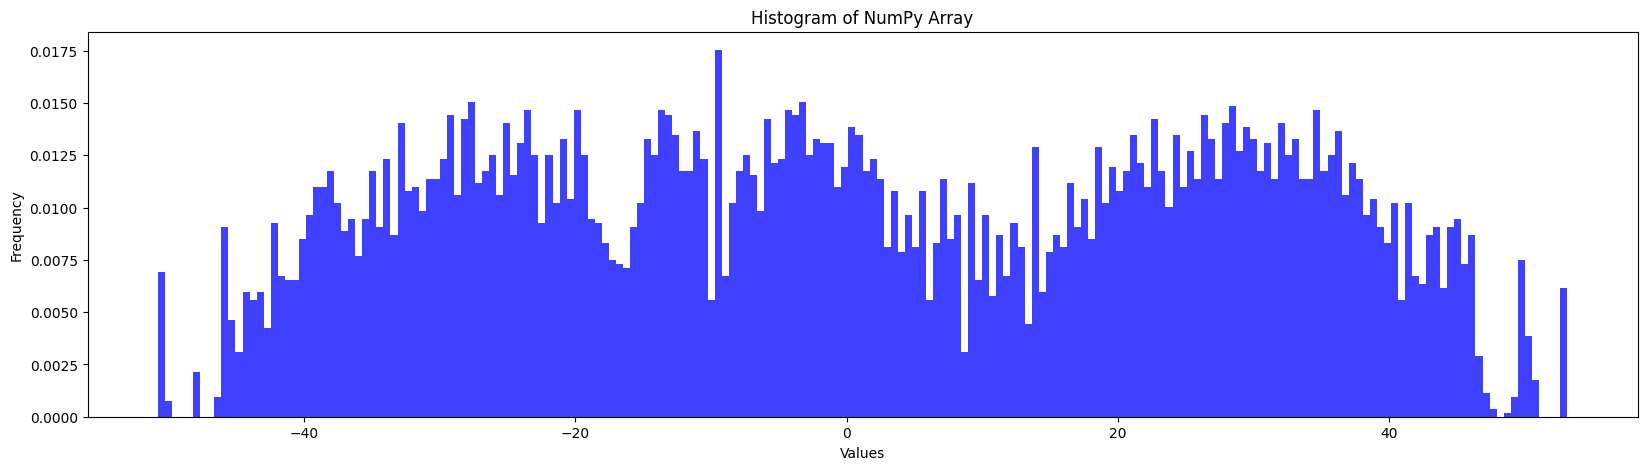

In [3]:
# bin
plt.figure(figsize=(20, 5))
plt.hist(state_array_1d, bins=bin_size, alpha=0.75, color='blue', density=True)

# 添加一些标签和标题
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of NumPy Array')

# 显示图形
plt.show()

In [4]:
counts, bin_edges = np.histogram(state_array_1d, bins=bin_size, density=True)

# 找到最高条形的索引
max_index = np.argmax(counts)

# 获取最高条形的值范围
max_bin_start = bin_edges[max_index]
max_bin_end = bin_edges[max_index + 1]

In [5]:
max_bin_start, max_bin_end

(-9.730079, -9.210869)

In [6]:
df_single = np.load(
    "/data2/mlqin/HFT4Ind/analysis_result/motivation/sample_result_tsne/single_df_target.npy",
)

In [7]:
indices = np.where((state_array_1d < max_bin_end) & (state_array_1d > max_bin_start))[0]
indices

array([1088, 1139, 1541, 1638, 1796, 1837, 1988, 2240, 2319, 2386, 2410,
       2411, 2458, 2733, 2734, 2849, 2922, 2923, 2924, 2998, 3233, 3234,
       3341, 3476, 3495, 3548, 3877, 3926, 4021, 4058, 4362, 4417, 4525,
       4927, 4964, 5063, 5085, 5122, 5300, 5578, 5580, 5915, 5948, 6009,
       6269, 6369, 6585, 6586, 6587, 6588, 6589, 6590, 6591, 6592, 6593,
       6594, 6595, 6774, 6808, 6809, 6810, 6827, 7338, 7401, 7559, 7987,
       8050, 8057, 8217, 8269, 8325, 8327, 8367, 8479, 8576, 8723, 8991,
       9295, 9315, 9334, 9513, 9591, 9617, 9618, 9661, 9695, 9713, 9759,
       9817, 9834, 9886])

In [8]:
def plot(df, index):
    # 设置图形大小
    plt.figure(figsize=(12, 6))  # Increased figure size for better clarity

    # 绘制数据点
    plt.plot(df.timestamp[15:], df['mark_price'][15:], '#F07673', marker='o', label='Future')
    plt.plot(df.timestamp[:16], df['mark_price'][:16], '#7998AD', label='State')

    # 设置y轴为整数
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

    # 添加图例，调整位置以防被切割
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=18)

    # 添加标题和轴标签，使用中文
    plt.xlabel('Timestamp', fontsize=21)
    plt.ylabel('Markprice', fontsize=21)

    # 调整边距以显示完整的x轴和图例

    # 显示图表
    plt.savefig('/data2/mlqin/HFT4Ind/analysis_result/motivation/tsne_result/similar_situation/df_{}.pdf'.format(index))  
    plt.close()


In [9]:
def calculate_price_differece(df):
    df["price_diff"] = df["mark_price"].shift(-1).values - df["mark_price"].values
    return df

In [10]:
df_list = []
for i, indice in zip(range(len(indices)), indices):
    df = pd.read_feather(
        "/data2/mlqin/HFT4Ind/analysis_result/motivation/sample_result_tsne/small_dfs/small_df_{}.feather".format(
            indice
        )
    )
    df = calculate_price_differece(df)
    plot(df, i)
    df_list.append(df)
diff_sum_list = []
pair_list = []

In [11]:
min_diff_sum = float("inf")
best_pair = None
for i in range(len(df_list) - 1):
    df1 = df_list[i]
    for j in range(i + 1, len(df_list)):
        df2 = df_list[j]
        diff = np.abs((df1["price_diff"].values - df2["price_diff"].values))
        # 计算前15个差的总和
        diff_sum = diff[:15].sum()
        future_diff_sum=diff[15:-1].sum()
        diff_sum_list.append(diff_sum-future_diff_sum)
        pair_list.append((i,j))
        if diff_sum < min_diff_sum:
            min_diff_sum = diff_sum
            best_pair = (i, j)
result_dict={}

In [12]:
for pair, diff_sum in zip(pair_list, diff_sum_list):
    result_dict[pair] = diff_sum
sorted_dict = dict(sorted(result_dict.items(), key=lambda item: item[1]))

In [13]:
sorted_dict

{(28, 88): -16.317078560015943,
 (30, 88): -10.493287409994082,
 (13, 88): -9.87688749001245,
 (9, 88): -9.118889450004644,
 (14, 88): -7.8271610800074995,
 (19, 88): -7.13501561999874,
 (17, 88): -6.914058950002072,
 (63, 88): -6.59898529000202,
 (52, 88): -6.428343500003393,
 (0, 88): -5.482842779998464,
 (2, 88): -5.352145489996474,
 (1, 88): -5.100930030013842,
 (37, 88): -4.938552020001225,
 (20, 88): -4.895171100015432,
 (53, 88): -4.671799399999145,
 (16, 88): -4.553447020014573,
 (31, 88): -4.387864870026533,
 (56, 88): -4.284970280001289,
 (21, 88): -3.905433840016485,
 (8, 88): -3.8507488500144973,
 (75, 88): -2.8336553500084847,
 (3, 88): -2.78611123999508,
 (36, 88): -2.680638910002017,
 (57, 88): -2.6755551399946853,
 (44, 88): -2.547175449999486,
 (54, 88): -2.2981719199888175,
 (9, 28): -2.1678026100016723,
 (86, 88): -1.6338902600109577,
 (46, 88): -1.4922231100063073,
 (55, 88): -0.9257523199994466,
 (49, 88): -0.30587761001152103,
 (5, 88): -0.10463936000451213,
 (45,

In [14]:
df=df_list[88]

In [15]:
df['mark_price']

10582    28079.330306
10583    28079.287690
10584    28078.891016
10585    28078.515686
10586    28078.234061
10587    28076.762047
10588    28076.421743
10589    28076.200000
10590    28080.600000
10591    28080.700000
10592    28079.900000
10593    28077.746088
10594    28077.674112
10595    28078.900000
10596    28077.687969
10597    28077.779810
10598    28077.746782
10599    28077.606473
10600    28099.500000
Name: mark_price, dtype: float64

In [16]:
def plot(df):
    # 设置图形大小
    plt.figure(figsize=(12, 6))  # Increased figure size for better clarity

    # 绘制数据点
    plt.plot(df.timestamp[:16], df['mark_price'][:16], '#7998AD', label='State')

    # 设置y轴为整数
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

    # 添加图例，调整位置以防被切割
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=18)

    # 添加标题和轴标签，使用中文
    plt.xlabel('Timestamp', fontsize=21)
    plt.ylabel('Markprice', fontsize=21)

    # 调整边距以显示完整的x轴和图例

    # 显示图表
    plt.savefig('/data2/mlqin/HFT4Ind/analysis_result/motivation/tsne_result/similar_situation/state.pdf')  
    plt.close()

In [17]:
plot(df)

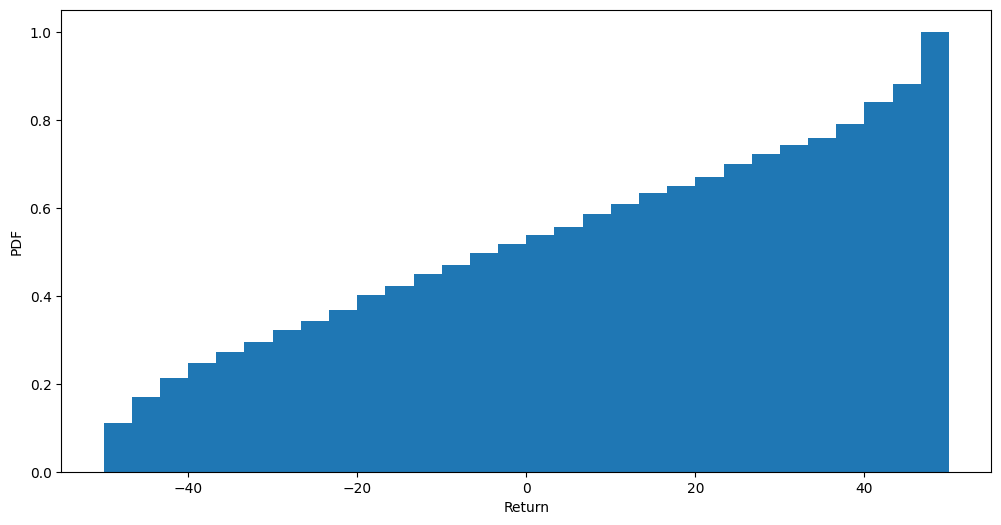

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Generating data from a normal distribution
# Generating data from a beta distribution with both alpha and beta less than 1
data_bimodal_transformed = np.random.beta(a=0.5, b=0.5, size=1000)
plt.figure(figsize=(12, 6))
# Transforming the data to fit the range -50 to +50
data_bimodal_transformed = (data_bimodal_transformed * 100) - 50

# Creating a histogram of the transformed bimodal data with density=True
plt.hist(data_bimodal_transformed, bins=30, density=True,cumulative=True)
plt.xlabel('Return')
plt.ylabel('PDF')
plt.savefig('/data2/mlqin/HFT4Ind/analysis_result/motivation/tsne_result/similar_situation/histogram.pdf') 

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Generating data from a beta distribution with both alpha and beta less than 1
data_bimodal_transformed = np.random.beta(a=0.5, b=0.5, size=1000)
# Transforming the data to fit the range -50 to +50
data_bimodal_transformed = (data_bimodal_transformed * 100) - 50

# Calculate the quantiles
quantiles = np.quantile(data_bimodal_transformed, np.linspace(0, 1, 30))
x_vals = np.linspace(0, 1, 30)

plt.figure(figsize=(10, 5))  # Reduced figure size for compactness
ax = plt.gca()  # Get current axis

# Plot each quantile against its value with better aesthetics
ax.scatter(x_vals, quantiles, color='deepskyblue', s=10,marker='x', label='Quantile Points')  # Enhance scatter visual
ax.plot(x_vals, quantiles, color='slategrey', alpha=0.8, linewidth=2.5, label='Quantile Line')  # Soft grey line

# Fill under the curve with two different colors
ax.fill_between(x_vals, quantiles, 0, where=(quantiles >= 0), interpolate=True, color='green', alpha=0.3, label='Profit')
ax.fill_between(x_vals, quantiles, 0, where=(quantiles <= 0), interpolate=True, color='red', alpha=0.3, label='Loss')

# Styling
ax.set_xlabel('Market Quantile', fontsize=18, fontweight='bold')
ax.set_ylabel('Q value', fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)  # Adjust label size

# Adjust legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=12)

# Improve the visual layout
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()  # Ensure everything fits without clipping

plt.savefig('/data2/mlqin/HFT4Ind/analysis_result/motivation/tsne_result/similar_situation/long_cdf.pdf')

plt.close()

In [20]:
data_bimodal_transformed = np.random.beta(a=0.5, b=0.5, size=1000)
# Transforming the data to fit the range -50 to +50
data_bimodal_transformed = (data_bimodal_transformed * 100) - 50

# Calculate the quantiles
quantiles = -np.quantile(data_bimodal_transformed, np.linspace(0, 1, 30))
x_vals = np.linspace(0, 1, 30)

plt.figure(figsize=(10, 5))  # Reduced figure size for compactness
ax = plt.gca()  # Get current axis

# Plot each quantile against its value with better aesthetics
ax.scatter(x_vals, quantiles, color='deepskyblue', s=10,marker='x', label='Quantile Points')  # Enhance scatter visual
ax.plot(x_vals, quantiles, color='slategrey', alpha=0.8, linewidth=2.5, label='Quantile Line')  # Soft grey line

# Fill under the curve with two different colors
ax.fill_between(x_vals, quantiles, 0, where=(quantiles >= 0), interpolate=True, color='green', alpha=0.3, label='Profit')
ax.fill_between(x_vals, quantiles, 0, where=(quantiles <= 0), interpolate=True, color='red', alpha=0.3, label='Loss')

# Styling
ax.set_xlabel('Market Quantile', fontsize=18, fontweight='bold')
ax.set_ylabel('Q value', fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)  # Adjust label size

# Adjust legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=12)

# Improve the visual layout
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()  # Ensure everything fits without clipping

plt.savefig('/data2/mlqin/HFT4Ind/analysis_result/motivation/tsne_result/similar_situation/short_cdf.pdf')

plt.close()

In [21]:
data_bimodal_transformed = np.random.beta(a=0.5, b=0.5, size=1000)
# Transforming the data to fit the range -50 to +50
data_bimodal_transformed = (data_bimodal_transformed * 100) - 50

# Calculate the quantiles
quantiles =np.array([0]*30)
x_vals = np.linspace(0, 1, 30)

plt.figure(figsize=(10, 5))  # Reduced figure size for compactness
ax = plt.gca()  # Get current axis

# Plot each quantile against its value with better aesthetics
ax.scatter(x_vals, quantiles, color='deepskyblue', s=10,marker='x', label='Quantile Points')  # Enhance scatter visual
ax.plot(x_vals, quantiles, color='slategrey', alpha=0.8, linewidth=2.5, label='Quantile Line')  # Soft grey line

# Fill under the curve with two different colors
ax.fill_between(x_vals, quantiles, 0, where=(quantiles >= 0), interpolate=True, color='green', alpha=0.3, label='Profit')
ax.fill_between(x_vals, quantiles, 0, where=(quantiles <= 0), interpolate=True, color='red', alpha=0.3, label='Loss')

# Styling
ax.set_xlabel('Market Quantile', fontsize=18, fontweight='bold')
ax.set_ylabel('Q value', fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)  # Adjust label size

# Adjust legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=12)

# Improve the visual layout
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()  # Ensure everything fits without clipping

plt.savefig('/data2/mlqin/HFT4Ind/analysis_result/motivation/tsne_result/similar_situation/close.pdf')

plt.close()

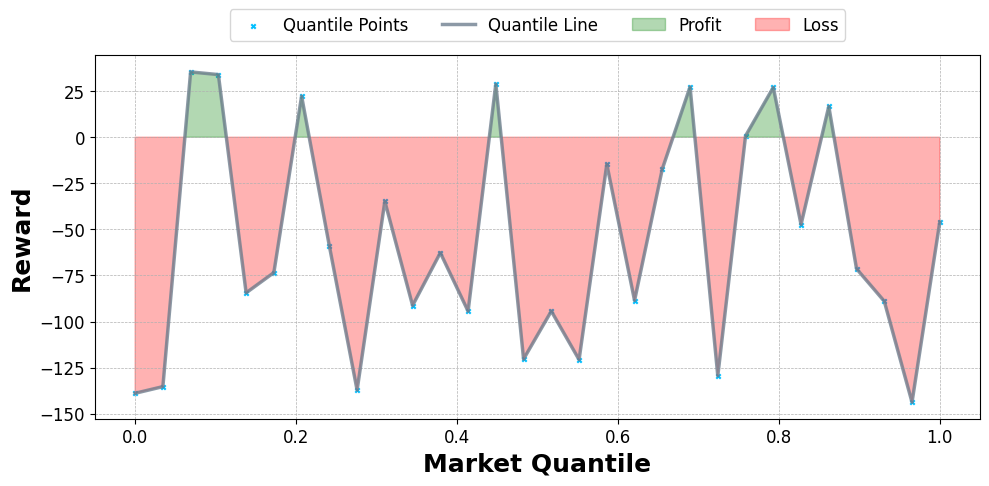

In [25]:
data_bimodal_transformed_1 = np.random.beta(a=0.5, b=0.5, size=1000)

data_bimodal_transformed_2 = np.random.beta(a=0.5, b=0.5, size=1000)
data_bimodal_transformed = data_bimodal_transformed_1 - data_bimodal_transformed_2
data_bimodal_transformed = (data_bimodal_transformed * 100) - 50

quantiles = np.random.choice(data_bimodal_transformed, size=30, replace=False)
x_vals = np.linspace(0, 1, 30)

plt.figure(figsize=(10, 5))  # Reduced figure size for compactness
ax = plt.gca()  # Get current axis

# Plot each quantile against its value with better aesthetics
ax.scatter(
    x_vals, quantiles, color="deepskyblue", s=10, marker="x", label="Quantile Points"
)  # Enhance scatter visual
ax.plot(
    x_vals,
    quantiles,
    color="slategrey",
    alpha=0.8,
    linewidth=2.5,
    label="Quantile Line",
)  # Soft grey line

# Fill under the curve with two different colors
ax.fill_between(
    x_vals,
    quantiles,
    0,
    where=(quantiles >= 0),
    interpolate=True,
    color="green",
    alpha=0.3,
    label="Profit",
)
ax.fill_between(
    x_vals,
    quantiles,
    0,
    where=(quantiles <= 0),
    interpolate=True,
    color="red",
    alpha=0.3,
    label="Loss",
)

# Styling
ax.set_xlabel("Market Quantile", fontsize=18, fontweight="bold")
ax.set_ylabel("Reward", fontsize=18, fontweight="bold")
ax.tick_params(axis="both", which="major", labelsize=12)  # Adjust label size

# Adjust legend
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=12)

# Improve the visual layout
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()  # Ensure everything fits without clipping